![logo](../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# A first step towards a strategic development of wind farms in northern Norway

Production date: 

Produced by: Fabio Mangini, Nansen Environmental and Remote Sensing Center (NERSC)   

## 🌍 Use case: Reanalysis datasets for an effective renewable energy facility planning in the European Arctic.

## ❓ Quality assessment question
* **Can ERA5 and CARRA be used to estimate wind energy production at a wind farm in northern Norway?** 

Renewable energy is central to achieving net‑zero carbon emissions, a key objective for mitigating climate change (e.g., Peters et al., 2017). Wind power, in particular, represents an important alternative to energy sources based on fossil fuels. This is thanks, for example, to its efficiency (Desalegn et al. 2023) and relatively simple installation and maintenance (Tanvir et al., 2025). 

Despite its potentials, though, wind energy production is severely affected by its inherent dependence on weather conditions. In this respect, examination of historical wind climate can help identify the most suitable sites where to build wind farms. However, long recording of wind speed are only available at a limited number of locations. 

Reanalysis datasets can complement in-situ observations, helping overcome their limited spatial and temporal coverage. Indeed, they offer continuous, gap‑free records derived by assimilation of observations and numerical weather prediction models. Some reanalysis datasets, such as those used in this assessment, also provide information about the state of the atmosphere at prescribed height levels. This makes them well suited for applications related to wind energy production, as wind turbines operate at fixed hub heights.

This assessment explores the ability of two reanalysis datasets, ERA5 (Hersbach et al., 2020), a global reanalysis, and CARRA on height levels, a regional reanalysis for the European Arctic, to estimate the energy production of an onshore wind farm in northern Norway, used as a case study. We propose focusing on an onshore wind farm of northern Norway partly because data about its energy production is readily available online, and partly because northern Norway is located within the eastern domain of CARRA. 

## 📢 Quality assessment statement
```{admonition} These are the key outcomes of this assessment
:class: note

* The assessment investigates the ability of ERA5, a global atmospheric reanalysis dataset, and CARRA, a regional reanalysis dataset for the Euopean sector of the Arctic, to reconstruct the wind energy genereated by the Kjøllefjord wind farm in northern Norway. 

* Wind energy estimates derived from both reanalysis datasets exhibit a good qualitative agreement with the observations at 3‑hourly and daily timescales. In this respect, lowering the temporal resolution to daily leads to a modest improvement in the agreement.

* ERA5 and CARRA return comparable results, despite ERA5 having a spatial resolution coarser than CARRA both in the horizontal and the vertical. 

* Additional analysis is needed before this assessment's results can be generalized, as the differences between CARRA and ERA5 manifests a high geographical variability depending, for example, on local topography and physiography. 
```

## 📋 Methodology

This assessment investigates the potential of using wind speed from ERA5 and CARRA to reconstruct the wind energy produced by the Kjøllefjord wind farm, in northern Norway, which is used as a case study. The assessment is based on the observed wind energy produced at the Kjøllefjord wind farm, which is used as ground truth to evaluate the wind energy estimated from ERA5 and CARRA. The estimation is made possible by knowing that the site consists of 17 turbines whose averaged hub height is 70m, and by using the turbine power curve provided at https://www.thewindpower.net/turbine_en_21_siemens_swt-2.3-82-vs.php The power curve defines the relationship between wind speed and the power generated by a single turbine. 

For ERA5, wind speed is computed from the zonal and meridional components at 100 m height, whereas for CARRA, wind speeds are retrieved at 75 m. These heights correspond to the height levels in ERA5 and CARRA that are closest to the average turbine hub height at the Kjøllefjord wind farm (70 m). The results are then compared with the observations. 

The analysis and results are organized as follows: 

**[](reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-1)**

**[](reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-2)** 

  * Wind energy at Norwegian wind farms
  * ERA5
  * CARRA

**[](reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-3)** 

  * Kjøllefjord wind farm
  * Reanalysis datasets

**[](reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-4)** 

**[](reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-5)** 

**[](reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-6)** 

## 📈 Analysis and results

(reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-1)=
### 1. Import required packages

The assessment is based on a set of python packages that are widely used by the climate community, with the addition of the 'c3s_eqc_automatic_quality_control' package, which is needed to include the "C3S EQC custom functions" prepared by B-Open. 

In [51]:
import tempfile

import fsspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr 
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from sklearn.linear_model import LinearRegression
from c3s_eqc_automatic_quality_control import diagnostics, download, plot, utils 
import calendar

plt.style.use("seaborn-v0_8-notebook") 

In [52]:
import os

os.environ["CDSAPI_RC"] = os.path.expanduser("~/mangini_fabio/.cdsapirc")

(reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-2)=
### 2. Description of the datasets

#### Wind energy at Norwegian wind farms

In [53]:
def map_wind_farm(lon_wf, lat_wf, name_wf):
    """
    This function creates a map of Northern Norway displaying the location of the wind farm included in this study. 

    Parameters 
    ----------
    lon_wf, lat_wf : float, float 
        Longitude and latitude of the wind farm included in this study     
    """
    
    # Draw figure 
    fig, ax = plt.subplots(1, 1, figsize=(4,4), subplot_kw={'projection':ccrs.Stereographic(central_latitude=65, central_longitude=14)})

    # Draw the coastline of Svalbard and highlight the location of the weather stations 
    ax.coastlines('10m')
    ax.set_extent([3,28,57,73])
    ax.scatter(lon_wf, lat_wf, c='lime', edgecolor='k', s=50, zorder=2, transform=ccrs.PlateCarree())

    # Write down the name of the weather stations
    ax.text(lon_wf, lat_wf-2, name_wf, ha='center',
            fontweight='regular', bbox=dict(facecolor='w', edgecolor='green', alpha=0.5), 
            transform=ccrs.PlateCarree())

    # Add colors for land, ocean 
    ax.add_feature(cfeature.LAND)      
    ax.add_feature(cfeature.OCEAN)  
    
    # Add country borders
    ax.add_feature(cfeature.BORDERS)
    
    # Draw coordinates 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--') 
    gl.top_labels = True
    gl.left_labels = True 
    gl.xlocator = mticker.FixedLocator([0, 5, 10, 15, 20, 25, 30, 35, 40])
    gl.ylocator = mticker.FixedLocator([60, 65, 70])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    plt.show()    

The wind energy produced by the Norwegian wind farms is provided by the Norwegian Water Resources and Energy Directorate (abbreviated as NVE, which stands "Noregs vassdrags- og energidirektorat") through the following URL: https://www.nve.no/media/19691/vindprod2002-2025_kraftverk_utcplus1.xlsx Data are available between 01/01/2002 and 31/12/2025, at a hourly temporal resolution and expressed in MWh. We should note that the wind energy production data are provided in UTC+1 but that, for a comparison with ERA5 and CARRA, this has been converted into UTC. 

As previously stated, this assessment examines wind energy production at the Kjøllefjord wind farm. The wind farm is located in northern Norway (Fig. 3.1.1), and consists of 17 turbines (model: Siemems SWT-2.3-82 VS), which have an average hub height of 70m (information found at https://www.nve.no/energi/energisystem/vindkraft-paa-land/data-for-utbygde-vindkraftverk-i-norge/). The site was chosen as a case study partly because it lies within the CARRA-East domain, away from its boundaries, and parly because it shows a relatively stable production history (Fig. 3.1.2). The temporal stability is of interest because it might indicate that variations in production at the Kjøllefjord wind farm are predominantly weather-driven rather than linked to human activity. However, during the most recent years, we note anomalies in wind energy production when compared to the preceding years. 

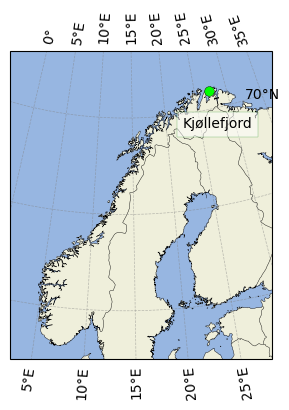

In [54]:
lon_wf = 27.35 
lat_wf = 70.95
map_wind_farm(lon_wf, lat_wf, 'Kjøllefjord')

*Map of Norway with the location and the name of the wind farm selected for this study.*

#### ERA5

This assessment uses the zonal and meridional components of the wind field at 100m height as provided by the ERA5 global reanalysis dataset (Hersbach et al., 2020). The dataset has a temporal resolution of 1 hour and spatial resolution of 0.25°x0.25°. 

#### CARRA

This assessment uses wind speed at 75m height as provided by CARRA on height levels, the regional reanalysis dataset for the European sector of the Arctic. The data have a temporal resolution of 3 hours, and horizontal spatial resolution of 2.5km. In the vertical, CARRA on height levels consists of 15 levels, ranging from 15m to 500m. 

(reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-3)=
### 3. Download datasets

#### Kjøllefjord wind farm

In [55]:
def open_wind_energy_data(): 

    wind_energy_url = ("https://www.nve.no/media/19691/vindprod2002-2025_kraftverk_utcplus1.xlsx") 
    with fsspec.open(f"simplecache::{wind_energy_url}") as fp:
        df_wind_energy = pd.read_excel(fp)

    # Reformat pd.DataFrame
    df_wind_energy = df_wind_energy.set_index('kraftverknavn').iloc[2:]
    df_wind_energy.index = pd.to_datetime(df_wind_energy.index - pd.Timedelta('1h')) 

    return df_wind_energy 


def plot_wind_energy_production_at_wind_farm(df_wind_energy, name_wf):
    """
    This function creates two plots. One shows the hourly wind energy production for the selected wind farm, 
    while the other the corresponding monthly climatology. 
    
    Parameters
    ----------
    df_wind_energy : pd.Series 
        Hourly wind energy produced by the Norwegian wind farms 

    name_wf : str 
        Name of the selected wind farm (whose wind energy production is shown).  
    """
    
    fig, axs = plt.subplots(2, 1, figsize=(20,14))

    # Show timeseries of the hourly wind energy produced by the selected wind farm 
    idx_no_nans = ~np.isnan(df_wind_energy[name_wf])
    df_wind_energy[name_wf][idx_no_nans].plot(ax=axs[0], c='C0') 

    # Compute and show the monthly climatology of the wind energy produced by the selected wind farm 
    sr_wind_energy_snc = df_wind_energy[name_wf].groupby(df_wind_energy[name_wf].index.month).mean() 
    sr_wind_energy_snc.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] 
    sr_wind_energy_snc.plot(ax=axs[1], marker='o', lw=2, c='C0')

    ls_titles = [f'Wind energy at {name_wf}', f'Monthly climatology of the wind energy at {name_wf}']
    for (iax, str_title) in zip(axs, ls_titles): 
        iax.set_xlabel(None)
        iax.set_ylabel('Wind energy [MWh]') 
        iax.set_title(str_title)
        iax.grid()
    
    plt.show() 

In [56]:
df_wind_energy = open_wind_energy_data()

As previously stated, this assessment examines the relationship between the wind speeds provided by two reanalysis datasets, ERA5 and CARRA, and the wind energy generated at the Kjøllefjord wind farm. To familiarise ourselves with the characteristics of the wind farm's production, we first summarise its properties using the hourly time series of wind energy and its monthly climatology, which has been computed to show the seasonal cycle (Fig. 3.1.2). 

Wind energy production data are available from 24/09/2006 to 31/12/2025. The hourly timeseries show an overall consistent evolution throughout most of this period, with values reaching up to approximately 40 MWh. The timeseries do not show a marked inter-annual variability, but the monthly climatology reveals a clear seasonal cycle, with values ranging from around 6 MWh in July to about 15 MWh in winter. The lower summer values possibly reflect weaker winds during that season. 

We should note that the production record exhibits anomalous behaviour at the very beginning of the time series (i.e., in the last months of 2006) and again from around early 2021 onwards. For this reason, the analysis is restricted to the period 01/01/2007 to 31/12/2020. 

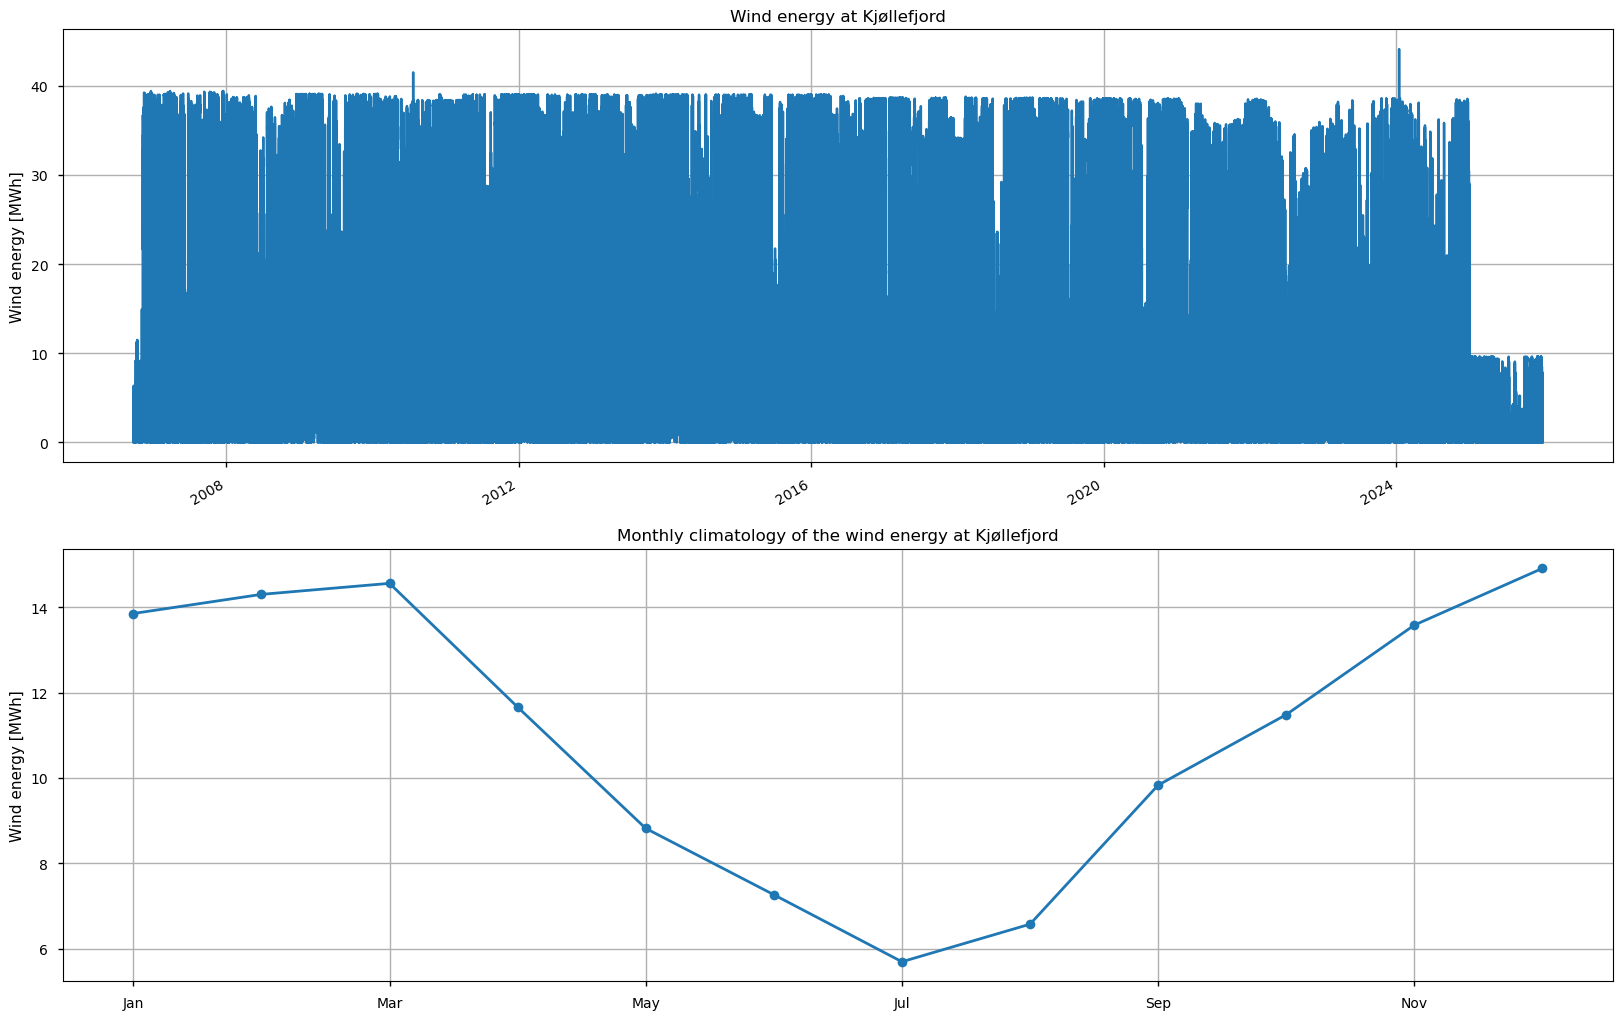

In [57]:
plot_wind_energy_production_at_wind_farm(df_wind_energy, 'Kjøllefjord') 

*(Above) Timeseries of wind energy, in MWh, produced each hour at the Kjøllefjord wind farm. (Below) Corresponding monthly climatology.* 

#### Reanalysis datasets

In [58]:
# %%
# Parameters
year_start = 2007
year_stop = 2025
area = [72, 22, 70, 29]

requests_dict = {
    "carra1_height": (
        "reanalysis-carra-height-levels",
        {
            "domain": "east_domain",
            "variable": ["wind_speed"],
            "height_level": ["75_m"],
            "product_type": "analysis",
            "data_format": "grib",
        },
    ),
    "era5": (
        "reanalysis-era5-single-levels",
        {
            "product_type": ["reanalysis"],
            "variable": [
                "100m_u_component_of_wind",
                "100m_v_component_of_wind",
            ],
            "area": area,
            "data_format": "grib",
            "download_format": "unarchived",
        },
    ),
}

# %%
datasets = {}
for name, (collection_id, request) in requests_dict.items():
    print(f"{name=}")

    requests = []
    for date in pd.date_range(f"{year_start}-01", f"{year_stop}-12", freq="1MS"):
        if (
            collection_id == "reanalysis-pan-carra"
            and str(date.year) not in pan_carra_years
        ):
            continue
        _, ndays = calendar.monthrange(date.year, date.month)
        time_request = {
            "time": [f"{hour:02d}:00" for hour in range(0, 24, 3)],
            "year": str(date.year),
            "month": date.strftime("%m"),
            "day": [f"{day:02d}" for day in range(1, ndays + 1)],
        }
        requests.append(request | time_request)

    if "area" in request:
        transform_func = None
        transform_func_kwargs = {}
    else:
        transform_func = utils.regionalise
        transform_func_kwargs = {
            "lon_slice": slice(area[1], area[3]),
            "lat_slice": slice(area[2], area[0]),
        }

    datasets[name] = download.download_and_transform(
        collection_id,
        requests,
        transform_func=transform_func,
        transform_func_kwargs=transform_func_kwargs,
        chunks={"variable": 1},
    )

name='carra1_height'


100%|██████████| 228/228 [00:13<00:00, 16.78it/s]


name='era5'


100%|██████████| 456/456 [00:12<00:00, 36.81it/s]
/data/common/miniforge3/envs/wp5/lib/python3.12/site-packages/earthkit/data/utils/kwargs.py:59: UserWarning: In xarray_open_dataset_kwargs backend_kwargs, overriding the default value (squeeze=False) with squeeze=True is not recommended.
  warnings.warn(


(reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-4)=
### 4. Kjøllefjord wind farm: wind speed from ERA5 and CARRA 

In [59]:
def dist_from_wind_farm(da_reanalysis, lon_wf, lat_wf):
    """
    Compute the distance (in km) between the wind farm and each grid point of a reanalysis dataset.
  
    Parameters
    ----------
    da_reanalysis : xr.DataArray
        The selected reanalysis dataset. 
  
    lon_wf, lat_wf : float, float
        Longitude and latitude of the wind farm. 
        
    Returns
    -------
    d : np.array 
        A 2D array (same shape as `da_reanalysis` spatial grid) containing the 
        distance in kilometers between each grid point and the wind farm.  
    """

    r = 6378.137    # Radius of the Earth (in km) 

    # np.arrays containing the longitude and latitude of the reanalysis data. 
    # These are 1D for ERA5, and 2D for CARRA. 
    lons_reanalysis = da_reanalysis.longitude.values
    lats_reanalysis = da_reanalysis.latitude.values

    # The 'if' statement checks whether the reanalyis considered is ERA5. 
    # If so, lons_reanalysis and lats_reanalysis are turned into 2D array
    # for them to have the shape of the ERA5's grid 
    if len(lons_reanalysis.shape) == 1:
        lons_reanalysis = np.tile(da_reanalysis.longitude.values, (len(da_reanalysis.latitude), 1))
        lats_reanalysis = np.tile(da_reanalysis.latitude.values, (len(da_reanalysis.longitude), 1)).T

    # Conversion: degrees to radians 
    lons_reanalysis_r = np.deg2rad(lons_reanalysis) 
    lats_reanalysis_r = np.deg2rad(lats_reanalysis) 
    lon_wf_r = np.deg2rad(lon_wf) 
    lat_wf_r = np.deg2rad(lat_wf) 

    d = r * np.arccos(np.sin(lats_reanalysis_r)*np.sin(lat_wf_r) + np.cos(lats_reanalysis_r)*np.cos(lat_wf_r)*np.cos(lons_reanalysis_r-lon_wf_r))
    
    return d
    

def reanalysis_data_at_wind_farm(da_reanalysis, lon_wf, lat_wf):
    """
    Select wind speed from one of the following reanalysis datasets: ERA5 or CARRA.
    
    The function retrieves the value of reanalysis dataset at the grid 
    point closest to the wind farm.

    Parameters
    ----------
    da_reanalysis : xr.DataArray
        3D array 
        3-hourly wind speed from ERA5 or CARRA.   
        
    lon_wf, lat_wf : list, list
        Longitude and latitude of the wind farm.  

    Returns
    -------
    sr_reanalysis_at_wf : pd.Series
        Values of da_reanalysis at the grid point closest to the wind farm.  
        
    """
    
    # Distance (in km) between the selected wind farm and each grid point of the reanalysis dataset 
    d_from_wf = dist_from_wind_farm(da_reanalysis, lon_wf, lat_wf)

    # Row and column indices of the grid point closest to the weather station  
    ind_row_wf = np.argmin(d_from_wf)//d_from_wf.shape[1]
    ind_col_wf = np.argmin(d_from_wf)%d_from_wf.shape[1]

    da_reanalysis_at_wf = da_reanalysis[:, ind_row_wf, ind_col_wf]
    sr_reanalysis_at_wf = da_reanalysis_at_wf.to_series()
    
    return sr_reanalysis_at_wf 

(reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-5)=
### 5. Kjøllefjord wind farm: wind energy estimates from ERA5 and CARRA

In [60]:
def wind_energy_from_wind_speed(sr_wind_speed_reanalysis): 
    """
    Given the wind speed, this function computes the wind energy generated at the Kjøllefjord wind farm. 
    It uses the energy curve of the Siemens SWT‑2.3‑82 VS turbine and assumes a total number of 17 turbines 
    at the site. 

    Parameters
    ----------
    sr_wind_speed_reanalysis : pd.Series 
        Timeseries of the wind speed from the reanalysis at the grid point closest to the wind farm location. 
    
    Results 
    ------- 
    sr_wind_energy_reanalysis : pd.Series 
        Timeseries of the wind energy at the wind farm as estimated from the reanalysis dataset. 
        Units: MWh. 
    """
    
    # Energy curve (kW) for wind speeds from 0 to 50 m/s in 0.5 m/s increments. 
    # (infor at https://www.thewindpower.net/turbine_en_21_siemens_swt-2.3-82-vs.php) 
    wp_swt_23_82vs = np.array([0, 
           0,    0,    0,    0,    0,    0,   30,   79,  121, 170, 
         227,  280,  345,  420,  510,  654,  778,  930, 1129, 1356, 
        1567, 1778, 1899, 2020, 2099, 2178, 2221, 2263, 2281, 2300, 
        2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 
        2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 2300, 
           0,    0,    0,    0,    0,     0,   0,    0,    0,    0,
           0,    0,    0,    0,    0,     0,   0,    0,    0,    0, 
           0,    0,    0,    0,    0,     0,   0,    0,    0,    0,
           0,    0,    0,    0,    0,     0,   0,    0,    0,    0,
           0,    0,    0,    0,    0,     0,   0,    0,    0,    0]) 

    # Wind energy generated by an individual turbine at each timestep. 
    wind_energy_reanalysis = np.interp(sr_wind_speed_reanalysis.values, np.r_[0:50.1:0.5], wp_swt_23_82vs) 
    sr_wind_energy_reanalysis = pd.Series(wind_energy_reanalysis, index=sr_wind_speed_reanalysis.index) 

    # Wind energy generated by all the turbines and conversion from kW to MWh 
    sr_wind_energy_reanalysis = 17 * 1e-3 * sr_wind_energy_reanalysis

    return sr_wind_energy_reanalysis

To assess how well ERA5 and CARRA reproduce the wind energy generated at the Kjøllefjord wind farm, we first need to estimate the wind energy that would result from wind speed provided by the reanalysis datasets. This estimation is based on the knowledge that the Kjøllefjord wind farm consists of 17 Siemens SWT‑2.3‑82 VS turbines (information found at https://www.nve.no/energi/energisystem/vindkraft-paa-land/data-for-utbygde-vindkraftverk-i-norge/). The turbine model is associated with a power curve (available at https://www.thewindpower.net/turbine_en_21_siemens_swt-2.3-82-vs.php), which is used to convert wind speed into energy. The resulting turbine-level output is then multiplied by the total number of turbines. 

In [61]:
# ERA5 wind speed at 100 m height 
datasets['era5']['ws100'] = np.sqrt(datasets['era5']['u100']**2 + datasets['era5']['v100']**2)

In [62]:
# Wind speed from ERA5 and CARRA at the Kjøllefjord wind farm 
sr_era5_ws_100m = reanalysis_data_at_wind_farm(datasets['era5']['ws100'], lon_wf, lat_wf)
sr_carra1_ws_075m = reanalysis_data_at_wind_farm(datasets['carra1_height']['ws'], lon_wf, lat_wf) 

In [63]:
# Wind energy at the Kjøllefjord wind farm as estimated from ERA5 and CARRA 
sr_wind_energy_era5_100m  = wind_energy_from_wind_speed(sr_era5_ws_100m)
sr_wind_energy_carra1_075m = wind_energy_from_wind_speed(sr_carra1_ws_075m)

(reanalysis_reanalysis-carra-height-levels_validation_q01:template:section-6)=
### 6. Kjøllefjord wind farm: comparison between observations and reanalysis estimates

In Fig. 3.1.3, we note a linear relationship between the observed and reconstructed wind energy generated at the Kjøllefjord wind farm between 01/01/2007 and 31/12/2020, with both the observed and reconstructed wind energy varying within a comparable range, from 0 to approximately 40MWh, and being characterized by a linear correlation exceeding 0.8. We note, however, some discrepancies between them. Notably, the reconstructed wind energy production from both ERA5 and CARRA appears to exceed the observed ones, as indicated by the positive biases. Despite the differeces, though, the overall results indicate that both the wind speed from ERA5 and CARRA have potential in reconstructing the wind energy production at the site. 

The comparison between the upper and the lower subplots indicate that, as we decrease the temporal resolution of the datasets from 3-hourly to daily, we obtain a less noisy relationship, an improvement in the correlation coefficients by a few decimal points, and of the standard deviation of the differences by few MWh. This results is consistent with the assumption that the daily-averaging filters out part of the random noise prensent in the reanalysis datasets. 

To conclude, we note that ERA5 and CARRA return comparable results, despite CARRA having a finer spatial resolution than ERA5, both in the horizontal and the vertical. However, we should highlight that this result cannot be easily generalized. A preliminary literature review shows that the Kjøllefjord wind farm is located in a region where the differences in 10m wind speed between CARRA and ERA5 is at a local minimum (Fig. 1c in Køltzow et al., 2022). Despite the figure showing results for the 10m height, this might explain why the two datasets return comparable results when it comes to wind energy production in the region. 

In this respect, future work might consider additional wind farms within CARRA's domain, and might possibly investigate the reasons why the finer spatial resolution of CARRA does not translate into a greater agreement with the observations. 

In [49]:
def wind_energy_obs_vs_est(sr_wind_energy, 
                           sr_wind_energy_era5_100m, sr_wind_energy_carra1_075m, 
                           date_beg, date_end): 
    """
    This function visualizes the relationship between the wind energy generated by the selected wind farm and the 
    wind energy estimated from ERA5 and CARRA. The comparison is presented using scatter plots arranged in a 2×2 grid. 
    The upper‑left and upper‑right panels show, respectively, the comparison between observed wind energy and the 
    estimates from ERA5 and from CARRA at a 3‑hourly resolution. The lower panels present the same comparison, but 
    using daily‑averaged values. 

    Parameters
    ---------- 
    sr_wind_energy, sr_wind_energy_era5, sr_wind_energy_carra : pd.Series, pd.Series, pd.Series 
        Respectively, wind energy produced by the selected wind farm and estimated from ERA5 and CARRA. 

    date_beg, date_end : str, str 
        Needed to select the period of interest (from date_beg to date_end) 
    """
    
    # Data at 3-hourly temporal resolution & time crop 
    sr_wind_energy_3h = sr_wind_energy.resample('3h').mean().loc[date_beg:date_end]
    sr_wind_energy_era5_100m_3h = sr_wind_energy_era5_100m.resample('3h').mean().loc[date_beg:date_end] 
    sr_wind_energy_carra1_075m_3h = sr_wind_energy_carra1_075m.resample('3h').mean().loc[date_beg:date_end] 

    # Data at daily temporal resolution & time crop 
    sr_wind_energy_d = sr_wind_energy.resample('d').mean().loc[date_beg:date_end]
    sr_wind_energy_era5_100m_d = sr_wind_energy_era5_100m.resample('d').mean().loc[date_beg:date_end] 
    sr_wind_energy_carra1_075m_d = sr_wind_energy_carra1_075m.resample('d').mean().loc[date_beg:date_end] 

    # Bias  
    bias_era5_100m_3h = np.mean(sr_wind_energy_era5_100m_3h - sr_wind_energy_3h)
    bias_carra1_075m_3h = np.mean(sr_wind_energy_carra1_075m_3h - sr_wind_energy_3h)

    bias_era5_100m_d = np.mean(sr_wind_energy_era5_100m_d - sr_wind_energy_d)
    bias_carra1_075m_d = np.mean(sr_wind_energy_carra1_075m_d - sr_wind_energy_d)
    
    ls_bias = [bias_era5_100m_3h, bias_carra1_075m_3h, bias_era5_100m_d, bias_carra1_075m_d] 

    # Standard deviation of the difference  
    std_era5_100m_3h = np.std(sr_wind_energy_era5_100m_3h - sr_wind_energy_3h)
    std_carra1_075m_3h = np.std(sr_wind_energy_carra1_075m_3h - sr_wind_energy_3h)

    std_era5_100m_d = np.std(sr_wind_energy_era5_100m_d - sr_wind_energy_d)
    std_carra1_075m_d = np.std(sr_wind_energy_carra1_075m_d - sr_wind_energy_d)
    
    ls_std = [std_era5_100m_3h, std_carra1_075m_3h, std_era5_100m_d, std_carra1_075m_d] 
    
    # Correlation coefficients 
    corr_era5_100m_3h = np.corrcoef(sr_wind_energy_3h.values, sr_wind_energy_era5_100m_3h.values)[0,1]
    corr_carra1_075m_3h = np.corrcoef(sr_wind_energy_3h.values, sr_wind_energy_carra1_075m_3h.values)[0,1]

    corr_era5_100m_d = np.corrcoef(sr_wind_energy_d, sr_wind_energy_era5_100m_d.values)[0,1]
    corr_carra1_075m_d = np.corrcoef(sr_wind_energy_d, sr_wind_energy_carra1_075m_d.values)[0,1]
    
    ls_corr = [corr_era5_100m_3h, corr_carra1_075m_3h, corr_era5_100m_d, corr_carra1_075m_d]
    
    # Scatter plots
    fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(20,18))

    axs[0,0].scatter(sr_wind_energy_3h.values, sr_wind_energy_era5_100m_3h.values, alpha=0.5, c='C0')
    axs[0,1].scatter(sr_wind_energy_3h.values, sr_wind_energy_carra1_075m_3h.values, alpha=0.5, c='C1')

    axs[1,0].scatter(sr_wind_energy_d.values, sr_wind_energy_era5_100m_d.values, alpha=0.5, c='C0')
    axs[1,1].scatter(sr_wind_energy_d.values, sr_wind_energy_carra1_075m_d.values, alpha=0.5, c='C1')
    
    ls_titles = ['ERA5 100m - 3-hourly', 'CARRA 75m - 3-hourly', 
                 'ERA5 100m - Daily', 'CARRA 75m - Daily']

    for i, iax in enumerate(axs.flatten()): 
        iax.plot(range(40), range(40), c='k', ls='--', lw=0.5)
        iax.text(0.05, 0.875, 
                 f'corr={round(ls_corr[i],2)} \nbias={round(ls_bias[i],2)} MWh \nstd diff={round(ls_std[i],2)} MWh', 
                 transform=iax.transAxes, fontsize=14, \
                 bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
        iax.tick_params(labelsize=12) 
        iax.grid() 

        iax.set_title(ls_titles[i], fontsize=12)

        if i%2==0:
            iax.set_ylabel('Estimated wind energy [MWh]', fontsize=12)
        if i//2==1:
            iax.set_xlabel('Recorded wind energy [MWh]', fontsize=12)
    
    plt.show() 

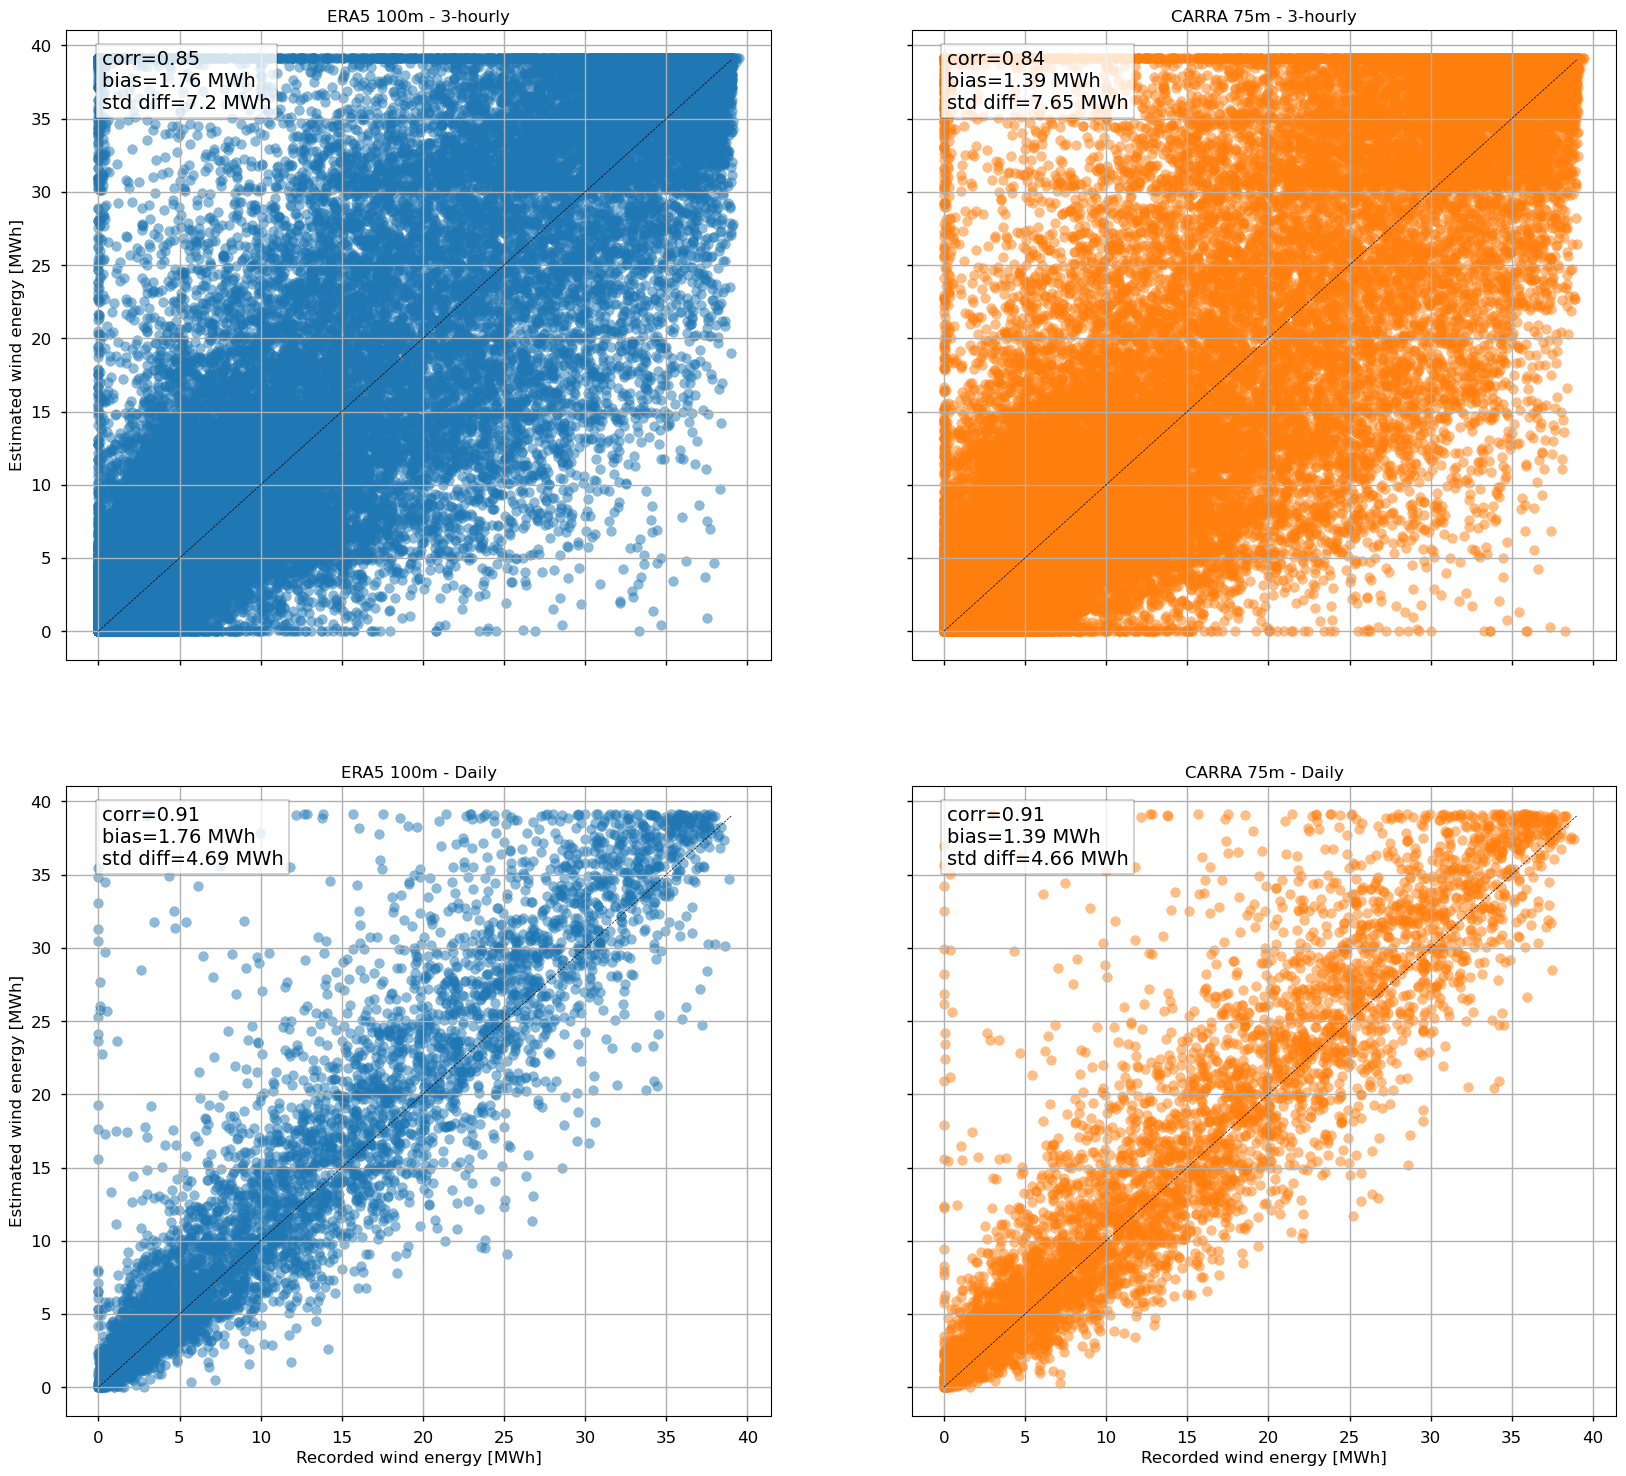

In [50]:
wind_energy_obs_vs_est(df_wind_energy['Kjøllefjord'], 
                       sr_wind_energy_era5_100m, sr_wind_energy_carra1_075m, 
                      '2007-01-01 00:00:00', '2020-12-31 23:59:59')

*Relationship between the wind energy generated by the selected wind farm and the wind energy estimated from ERA5 and CARRA. The comparison is presented using scatter plots arranged in a 2×2 grid. The upper‑left and upper‑right panels show, respectively, the comparison between observed wind energy and the estimates from ERA5 and from CARRA at a 3‑hourly resolution. The lower panels present the same comparison, but using daily‑averaged values. The upper-left corner of each subplot shows the bias of the estimated wind energy production with respect to the observed one, the standard deviation of their difference, and the linear correlation between the two time series.* 

## ℹ️ If you want to know more

### Key resources

CDS dataset used:

* [Arctic regional reanalysis on height levels from 1991 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-height-levels?tab=overview)

Code libraries used:

* [datetime](https://docs.python.org/3/library/datetime.html)
* [numpy](https://numpy.org/)
* [pandas](https://pandas.pydata.org/) 
* [xarray](https://docs.xarray.dev/en/stable/) 
* [matplotlib](https://matplotlib.org/) 
* [cartopy](https://scitools.org.uk/cartopy/docs/latest/) 
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`,  prepared by [B-Open](https://www.bopen.eu/)

Additional resources: 

* [Information on wind energy generated by wind farms over land on the Norwegian Water Resources and Energy Directorate](https://www.nve.no/energi/energisystem/vindkraft-paa-land/)

* [Information on the advantage of wind power](https://www.enel.com/learning-hub/renewables/wind-energy/advantages) 

* [Overview on wind energy production on the International Energy Agency (IEA) website](https://www.iea.org/energy-system/renewables/wind) 

### References 

* Desalegn, B., Gebeyehu, D., Tamrat, B., Tadiwose, T. 2023. Wind energy-harvesting technologies and recent research progresses in wind farm control models. Front. Energy Res., 11, p. 81, 10.3389/FENRG.2023.1124203/BIBTEX. 

* Hersbach, H., Bell, B., Berrisford, P., Hirahara, S., Horányi, A., et al. 2020 The ERA5 global reanalysis. Q.J.R. Meteorol. Soc. 146, 1990–2049. https://doi.org/10.1002/qj.3803

* Køltzow, M., Schyberg, H., Støylen, E., & Yang, X. (2022). Value of the Copernicus Arctic Regional Reanalysis (CARRA) in representing near-surface temperature and wind speed in the north-east European Arctic. Polar Research, 41. https://doi.org/10.33265/polar.v41.8002 

* Peters, G. P., Andrew, R. M., Canadell, J. G., Fuss, S., Jackson, R. J., et al. 2017. Key indicators to track current progress and future ambition of the Paris Agreement. Nat. Clim. Change 7, 118–122. 

* Tanvir, M. S., Etminan, A. 2025. Comparative analysis of offshore and onshore wind turbines: Efficiency, design, and environmental impact. Wind Eng., 50, 200–215. https://doi.org/10.1177/0309524X251386646 